In [1]:
!date

Wed Sep 16 11:10:35 PDT 2026


In [2]:
import pandas as pd
import matplotlib.pyplot as plt

projdir = '/u/project/cluo/terencew/claude/project_ideas/asm_lr_hprc2'

In [3]:
### Part 1: chain-file gap structure as a cheap haplotype-specific-SV proxy.
### No new alignment needed -- the liftover chain files already encode where each
### haplotype's assembly diverges structurally from hg38 (a nonzero dt/dq between
### consecutive aligned blocks is a gap/indel). Parsed for 15 donors (3 per
### superpopulation) -- see results/qc/data/chain_gaps_raw.tsv for the raw parse.
gaps = pd.read_csv(f'{projdir}/results/qc/data/chain_gaps_raw.tsv', sep='\t')

In [4]:
gaps.head()

,sample,superpopulation,hap,dt,dq,gap_size
0,HG00097,EUR,1,2,0,2
1,HG00097,EUR,1,5,0,5
2,HG00097,EUR,1,0,2,2
3,HG00097,EUR,1,12,0,12
4,HG00097,EUR,1,45,33,45


In [5]:
gaps.shape

(24432679, 6)

In [6]:
gaps['gap_size'].describe()

count    2.443268e+07
mean     2.070249e+02
std      4.215976e+04
min      1.000000e+00
25%      1.000000e+00
50%      2.000000e+00
75%      4.000000e+00
max      3.495142e+07
Name: gap_size, dtype: float64

In [7]:
### gap size is overwhelmingly small (median 2bp -- ordinary short indels), but the
### tail matters: gaps >=50bp are structural-variant-scale by the standard SV definition
summaries = {}
for thresh, label in [(1, 'all_gaps'), (50, 'sv_ge50bp'), (1000, 'large_ge1kb')]:
    sub = gaps[gaps['gap_size'] >= thresh]
    s = sub.groupby(['sample','superpopulation','hap']).agg(
        n_gaps=('gap_size','count'), total_gap_bases=('gap_size','sum')).reset_index()
    summaries[label] = s
summaries['sv_ge50bp'].groupby('superpopulation')[['n_gaps','total_gap_bases']].mean()

,n_gaps,total_gap_bases
superpopulation,,
AFR,26164.333333,1.674894e+08
AMR,24298.833333,1.637580e+08
EAS,24464.666667,1.638473e+08
EUR,23999.500000,1.729230e+08
SAS,23912.166667,1.585092e+08


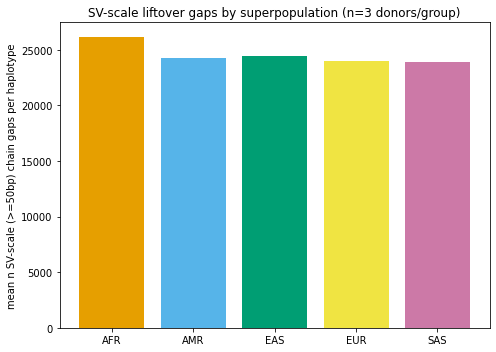

In [8]:
### AFR shows the most SV-scale gaps per haplotype (~26.2K vs EUR's 24.0K, ~9% more),
### same direction as this session's het-SNP-density finding (AFR ~37% higher) but a
### more modest effect size for this variant class
fig, ax = plt.subplots(figsize=(7,5))
sv = summaries['sv_ge50bp']
superpop_colors = {'AFR': '#E69F00', 'AMR': '#56B4E9', 'EAS': '#009E73',
                    'EUR': '#F0E442', 'SAS': '#CC79A7'}
order = ['AFR','AMR','EAS','EUR','SAS']
means = sv.groupby('superpopulation')['n_gaps'].mean().reindex(order)
ax.bar(order, means, color=[superpop_colors[s] for s in order])
ax.set_ylabel('mean n SV-scale (>=50bp) chain gaps per haplotype')
ax.set_title('SV-scale liftover gaps by superpopulation (n=3 donors/group)')
plt.tight_layout()

In [9]:
### within-donor hap1-vs-hap2 asymmetry -- ancestry held constant, so this isolates
### donor-specific structural variation as the driver, not population background
piv = sv.pivot(index=['sample','superpopulation'], columns='hap', values='total_gap_bases').reset_index()
piv.columns = ['sample','superpopulation','hap1_bases','hap2_bases']
piv['pct_diff'] = 100*abs(piv['hap1_bases']-piv['hap2_bases']) / piv[['hap1_bases','hap2_bases']].mean(axis=1)
piv.sort_values('pct_diff', ascending=False)

,sample,superpopulation,hap1_bases,hap2_bases,pct_diff
10,HG01891,AFR,128945079,167372925,25.936896
5,HG00438,EAS,198443640,157267795,23.151263
2,HG00126,EUR,192977799,163128484,16.764273
6,HG00639,AMR,169801275,197739482,15.202780
13,HG02698,SAS,163035658,141547062,14.110187
1,HG00099,EUR,184330729,160338902,13.921637
8,HG00735,AMR,168954740,151380722,10.972259
11,HG01960,AFR,170062960,185811872,8.850815
3,HG00408,EAS,166055963,155096189,6.825284
14,HG02735,SAS,174909549,164056675,6.403514


In [10]:
print(f"mean within-donor hap1-vs-hap2 %% diff in SV-scale unliftable bases: {piv['pct_diff'].mean():.1f}%")
print(f"max: {piv['pct_diff'].max():.1f}% ({piv.loc[piv['pct_diff'].idxmax(), 'sample']})")

mean within-donor hap1-vs-hap2 %% diff in SV-scale unliftable bases: 10.3%
max: 25.9% (HG01891)


In [11]:
### Part 2: does this asymmetry actually show up downstream, in post-liftover CpG counts?
### Uses P03's production hg38-anchored matrix (results/all_donors/per_sample_chrom/) --
### job 14764741 was still running when this was built, so only donors it had already
### reached (all EUR/EAS/AMR here -- it processes samples in manifest order, hadn't
### reached AFR/SAS yet) have complete per-chrom output. One file (HG00639, one chrom)
### was mid-write on first read (truncated gzip) -- re-read after the array task finished;
### all 8 donors below have all 22 autosomes.
balance = pd.read_csv(f'{projdir}/results/qc/data/postliftover_hap_balance.tsv', sep='\t')
balance

,sample,n_chroms,hap1_cpgs,hap2_cpgs,hap1_support,hap2_support,cpg_ratio,cpg_pct_diff
0,HG00097,22,68079882,67962877,672178743,671458087,1.001722,0.172012
1,HG00099,22,96978824,96883274,762252589,763008841,1.000986,0.098575
2,HG00126,21,67403266,67532862,832562464,835630241,0.998081,0.192085
3,HG00408,22,111783683,111473498,911130568,908393083,1.002783,0.277872
4,HG00423,21,112795134,112872133,764666883,764526559,0.999318,0.068241
5,HG00438,22,109349698,109242492,864688492,863349144,1.000981,0.098088
6,HG00639,22,104391587,104585742,788901386,790066974,0.998144,0.185814
7,HG00642,22,120721172,120398452,901843226,898811772,1.002680,0.267685


In [12]:
print(f"post-liftover hap1-vs-hap2 CpG-count %% diff: mean={balance['cpg_pct_diff'].mean():.3f}%%, "
      f"max={balance['cpg_pct_diff'].max():.3f}%%")

post-liftover hap1-vs-hap2 CpG-count %% diff: mean=0.170%%, max=0.278%%


In [13]:
### The connection this was actually testing: do donors with more asymmetric chain
### gaps between their own two haplotypes also show more post-liftover CpG-count
### imbalance? Only 6 of these 8 donors overlap the 15-donor chain-gap set (the other
### 2, HG00639/HG00642, weren't in that subset) -- merge on what's available.
merged = balance.merge(piv[['sample','pct_diff']], on='sample', how='inner',
                        suffixes=('_postliftover_cpg', '_chaingap'))
merged[['sample','cpg_pct_diff','pct_diff']].rename(
    columns={'cpg_pct_diff':'postliftover_cpg_pct_diff','pct_diff':'chain_gap_pct_diff'})

,sample,postliftover_cpg_pct_diff,chain_gap_pct_diff
0,HG00097,0.172012,6.381834
1,HG00099,0.098575,13.921637
2,HG00126,0.192085,16.764273
3,HG00408,0.277872,6.825284
4,HG00423,0.068241,2.925135
5,HG00438,0.098088,23.151263
6,HG00639,0.185814,15.202780
7,HG00642,0.267685,1.203314


In [14]:
!date

Wed Sep 16 11:10:56 PDT 2026
